In [ ]:
import sys
# Add your lenscarf site-packages to the path
sys.path.append('/users/odarwish/lenscarf/lib/python3.12/site-packages')

import numpy as np

sys.path.append('/users/odarwish/nbodykit/')
import nbodykit
from nbodykit.lab import ArrayCatalog

import matplotlib.pyplot as plt

sys.path.append('/users/odarwish/abacusutils/')

from abacusnbody.data.read_abacus import read_asdf

import numpy as np

from abacusnbody.analysis.tsc import tsc_parallel

import matplotlib.pyplot as plt

from abacusnbody.analysis.power_spectrum import calc_power, calc_pk_from_deltak, get_k_mu_edges
from abacusnbody.analysis import power_spectrum as ps

from scipy.fft import rfftn, irfftn

import astropy

from classy import Class

import yaml

In [2]:
from abacusnbody.analysis.power_spectrum import calc_power
from abacusnbody.data import read_abacus
from pathlib import Path

In [3]:
from nbodykit.lab import *

In [4]:
scratch = "/capstor/scratch/cscs/odarwish/ABACUS/"

In [5]:
z = 0.5

In [6]:
if False:
    if False:
        NN = 33
        directory = f"{scratch}/AbacusSummit_base_c000_ph000/halos/z0.500/field_rv_A/"
        pos_f = [read_asdf(directory+f"field_rv_A_{i:03}.asdf", ['pos']) for i in range(NN)]
        pos_field = astropy.table.vstack(pos_f)
        np.save(scratch+"pos_field_file.npy", pos_field)
    else:
        pos_field = np.load(scratch+"pos_field_file.npy")

In [7]:
if False:
    NN = 33
    directory = f"{scratch}/AbacusSummit_base_c000_ph000/halos/z0.500/halo_rv_A/"
    pos = [read_asdf(directory+f"halo_rv_A_{i:03}.asdf", ['pos']) for i in range(NN)]
    directory = f"{scratch}/AbacusSummit_base_c000_ph000/halos/z0.500/field_rv_A/"
    pos_f = [read_asdf(directory+f"field_rv_A_{i:03}.asdf", ['pos']) for i in range(NN)]
    pos = astropy.table.vstack(pos+pos_f)
    np.save(scratch+"pos_file.npy", pos)
else:
    pos = np.load(scratch+"pos_file.npy")

In [8]:
box = 2000
nthread = 256
ngrid = 576*2

In [9]:
interlaced = True
compensated = True
paste = 'TSC'
nbins_mu = 4
logk = False
k_hMpc_max = np.pi * ngrid / box + 1.0e-6
nbins_k = ngrid // 2
nthread = 128
dtype = np.float32

In [10]:
poles = [0]

kmin_vol = 2*np.pi/box

power_alt = calc_power(
    pos["pos"],
    box,
    nbins_k,
    nbins_mu,
    k_hMpc_max,
    logk,
    paste,
    ngrid,
    compensated,
    interlaced,
    poles=poles,
)

In [11]:
if False:
    power_field = calc_power(
        pos_field["pos"],
        box,
        nbins_k,
        nbins_mu,
        k_hMpc_max,
        logk,
        paste,
        ngrid,
        compensated,
        interlaced,
        poles=poles,
    )

In [12]:
with open('config_abacus.yaml', 'r') as f:
    config = yaml.safe_load(f)
gen_nl_power = np.loadtxt(config['power_spectrum']['nonlinear'])

(0.0031415926535897933, 36.8198059600527)

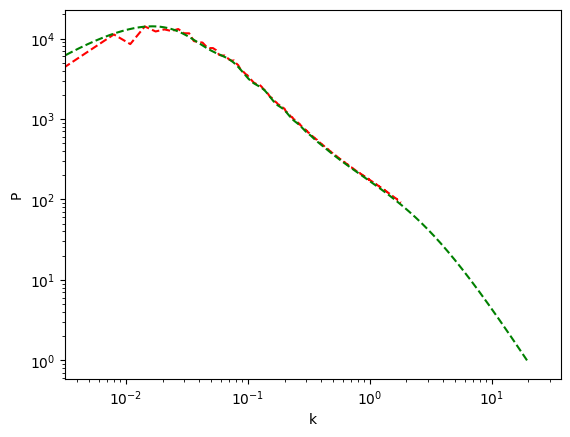

In [13]:
index = 1

plt.loglog(power_alt['k_avg'][:, index], power_alt['power'][:, index], ls = "--", c = "r")

plt.plot(gen_nl_power[:,0], gen_nl_power[:,1], ls='--', c='g')

plt.xlabel("k")
plt.ylabel("P")
plt.xlim(kmin_vol)
#plt.ylim(100)

In [14]:
from abacusnbody.analysis import tsc
delta = tsc.tsc_parallel(pos['pos'], ngrid, box, nthread=nthread)
delta /= np.mean(delta, dtype=np.float64)
delta -= 1.

In [15]:
del pos

In [16]:
from scipy.fft import rfftn, irfftn, fftfreq, rfftfreq
def get_kgrid(N):
    return 2 * np.pi * np.stack(
        np.meshgrid(
            fftfreq(N, d=box/N), fftfreq(N, d=box/N), rfftfreq(N, d=box/N),
            indexing='ij',
            )
        )

In [17]:
#k = (fftfreq(nmesh, d=d) * 2.0 * np.pi).astype(np.float32)  # h/Mpc

W = ps.get_W_compensated(box, ngrid, paste, interlaced)

In [18]:
kgrid = get_kgrid(delta.shape[0])
print(kgrid.shape)
kmag = (kgrid**2).sum(axis=0)**0.5
print(kmag.shape)

(3, 1152, 1152, 577)
(1152, 1152, 577)


In [19]:
field_fft = rfftn(delta, overwrite_x=False, workers=nthread)
field_fft *= 1 / delta.size

In [30]:
inv_size = dtype(1 / delta.size)
field_fft = rfftn(delta, overwrite_x=True, workers=nthread)
ps._normalize(field_fft, inv_size, nthread=nthread)
field_fft /= (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
)

In [21]:
poles = np.array([0])
k_max = np.pi * ngrid / box
mubins = nbins_mu
logk = False
kbins = ngrid
kbins, mubins = get_k_mu_edges(box, k_max, kbins, mubins, logk)

In [22]:
"""
paste = 'TSC'
field_fft = ps.get_field_fft(
        pos['pos'],
        box,
        ngrid,
        paste,
        None,
        W,
        compensated,
        interlaced,
        nthread=nthread,
        dtype=np.float32,
    )
"""

"\npaste = 'TSC'\nfield_fft = ps.get_field_fft(\n        pos['pos'],\n        box,\n        ngrid,\n        paste,\n        None,\n        W,\n        compensated,\n        interlaced,\n        nthread=nthread,\n        dtype=np.float32,\n    )\n"

In [31]:
power_delta = calc_pk_from_deltak(
    field_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [24]:
output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']

(0.0031415926535897933, 36.8198059600527)

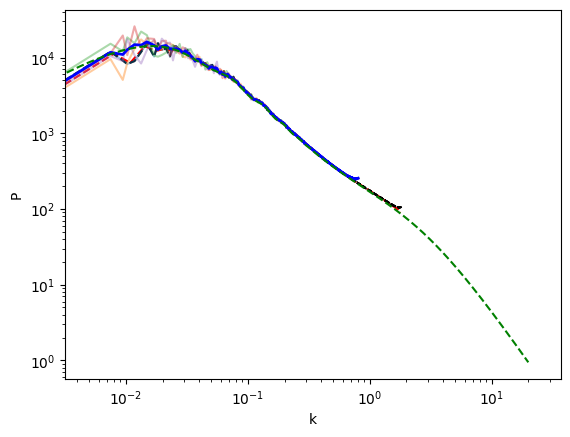

In [32]:
index = 1

plt.loglog(power_alt['k_avg'][:, index], power_alt['power'][:, index], ls = "--", c = "r")

#plt.loglog(power_field['k_avg'][:, index], power_field['power'][:, index], ls = "", c = "r", marker = "o")


plt.loglog(power_delta['k_avg'][:, index], power_delta['power'][:, index], ls = "--", c = "k")

idxs = [0, 1, 2, 3, 4]
mean = 0
for sim_idx in idxs:
    power_product_file = np.load(output_dir/f'power_delta_{sim_idx:03}.npy', allow_pickle = True).item()
    plt.plot(power_product_file['k_avg'][:, index], power_product_file['power'][:, index], alpha = 0.4)
    mean += power_product_file['power'][:, index]
plt.plot(power_product_file['k_avg'][:, index], mean/len(idxs), lw = 2, color = "blue")

plt.plot(gen_nl_power[:,0], gen_nl_power[:,1], ls='--', c='g')

plt.xlabel("k")
plt.ylabel("P")
plt.xlim(kmin_vol)
#plt.ylim(100)

In [33]:
from abacusnbody.metadata import get_meta
from abacusnbody.hod.zcv.ic_fields import load_dens, load_disp

sim_name = config['sim_params']['sim_name']
z = config['sim_params']['z_mock']

meta = get_meta(sim_name, redshift=z)

z_ic = meta['InitialRedshift']

Dz = meta['GrowthTable']
ztarget = 0.5
zpk = meta['ZD_Pk_file_redshift']  # 1.0
pk = meta['CLASS_power_spectrum']
k  = pk['k (h/Mpc)']
input_pk = pk['P (Mpc/h)^3']
linear_pk = input_pk * (Dz[ztarget] / Dz[zpk])**2

gen_power = np.loadtxt(config['power_spectrum']['linear'])


In [34]:
D_ratio = meta['GrowthTable'][meta['Redshift']] / meta['GrowthTable'][z_ic]
D_ratio

59.91148545808563

In [35]:
sim_name = config['sim_params']["sim_name"]
ic_dir = "/users/odarwish/scratch/ABACUS/ic/"
ic = load_dens(ic_dir, sim_name, ngrid)
del ic

In [36]:
disp_x, disp_y, disp_z = load_disp(ic_dir, sim_name, ngrid)
f_growth = 0.0
disp_pos = np.zeros((ngrid**3, 3), np.float32)
disp_pos[:, 0] = disp_x[:, :, :].flatten() * D_ratio
disp_pos[:, 1] = disp_y[:, :, :].flatten() * D_ratio
disp_pos[:, 2] = disp_z[:, :, :].flatten() * D_ratio * (1 + f_growth)
grid_x, grid_y, grid_z = np.meshgrid(
            np.arange(ngrid, dtype=np.float32) / ngrid,
            np.arange(ngrid, dtype=np.float32) / ngrid,
            np.arange(ngrid, dtype=np.float32) / ngrid,
            indexing='ij',
        )
grid_x = grid_x.flatten()
grid_y = grid_y.flatten()
grid_z = grid_z.flatten()

disp_pos[:, 0] += grid_x
disp_pos[:, 1] += grid_y
disp_pos[:, 2] += grid_z
del grid_x, grid_y, grid_z, disp_x, disp_y, disp_z 
Lbox = meta['BoxSize']
disp_pos *= Lbox

In [38]:
ic = load_dens(ic_dir, sim_name, ngrid)
ic_fft = rfftn(ic, overwrite_x=False, workers=nthread)
ic_fft /= ic.size
del ic

In [37]:
from abacusnbody.analysis.power_spectrum import (
    calc_pk_from_deltak,
    get_field_fft,
    get_k_mu_edges,
    get_W_compensated,
)

field_fft_disp_base = get_field_fft(
            disp_pos, Lbox, ngrid, paste, None, W, compensated, interlaced
            )

field_fft_disp = get_field_fft(
            disp_pos-Lbox/2, Lbox, ngrid, paste, None, W, compensated, interlaced
            )

del disp_pos

In [32]:
power_disp = calc_pk_from_deltak(
    field_fft_disp,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [34]:
power_ic = calc_pk_from_deltak(
    ic_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

(0.0031415926535897933, 166.23669538741154)

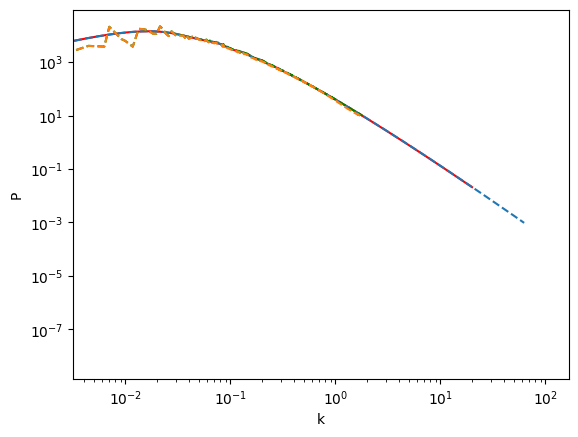

In [35]:
index = 0


plt.plot(gen_power[:,0], gen_power[:,1], ls='-', c = 'r')

plt.loglog(k, linear_pk, ls = "--")

plt.loglog(power_ic['k_avg'][:, index], power_ic['power'][:, index]*D_ratio**2, ls = "--", c = "g")

plt.plot(power_disp['k_avg'][:, index], power_disp['power'][:, index], ls = "--")

plt.xlabel("k")
plt.ylabel("P")
plt.xlim(kmin_vol)
#plt.ylim(100)

In [36]:
power_ic_cross = calc_pk_from_deltak(
    ic_fft,
    box,
    kbins,
    mubins,
    field2_fft=field_fft,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [37]:
power_disp_cross_ini = calc_pk_from_deltak(
    field_fft_disp,
    box,
    kbins,
    mubins,
    field2_fft=ic_fft,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [39]:
if False:
    delta_n = tsc.tsc_parallel(pos['pos'] + Lbox / 2.0, ngrid, box, nthread=nthread)
    delta_n /= np.mean(delta_n, dtype=np.float64)
    delta_n -= 1.
    field_fft_n = rfftn(delta_n, overwrite_x=False, workers=nthread)
    field_fft_n *= 1 / delta_n.size
    
    power_disp_cross = calc_pk_from_deltak(
        field_fft_disp,
        box,
        kbins,
        mubins,
        field2_fft=field_fft_n,
        poles=poles,
        squeeze_mu_axis=True,
        nthread=128,
    )
    
    index = 0
    
    #HERE THERE IS A ZERO CROSS-CORRELATION!!
    #WHY IS THAT? IN PRINCIPLE, THESE SHOULD BE CORRELATED
    
    plt.plot(gen_power[:,0], gen_power[:,1], ls='-', c = 'r', label = "Linear power")
    
    #plt.loglog(power_ic_cross['k_avg'][:, index], power_ic_cross['power'][:, index]*D_ratio**2, ls = "--", c = "g")
    
    plt.loglog(power_disp_cross['k_avg'][:, index], power_disp_cross['power'][:, index], ls = ":", c = "k")
    
    plt.loglog(power_disp_cross_ini['k_avg'][:, index], power_disp_cross_ini['power'][:, index]*D_ratio, ls = ":", c = "b")
    
    
    plt.xlabel("k")
    plt.ylabel("P")
    plt.xlim(kmin_vol)
    plt.legend()
    #plt.ylim(100)

In [40]:
if False:
    from nbodykit.source.mesh.field import FieldMesh
    import nbodykit
    from nbodykit.lab import ArrayCatalog, ArrayMesh
    from pmesh.pm import ParticleMesh
    import jax.numpy as jnp
    
    class Smoother(object):
        """
        Class to apply smoothing to field.
        """
        def __init__(self):
            raise NotImplementedError
    
        def get_smoothing_kernel_of_Nth_iteration(self, N):
            raise NotImplementedError
    
    class HardSmoother(Smoother):
        """
        Apply Gaussian smoothing to field.
        """
        def __init__(
            self,
            kmin, kmax,
            name='HardSmoother'
            ):
            self.kmin = kmin
            self.kmax = kmax
            self.name = name
    
        def get_smoothing_kernel(self):
            kmin, kmax = self.kmin, self.kmax
            if kmin is None or kmax==0.:
                def kernel_fcn(k3vec, val):
                    return val
            else:
                def kernel_fcn(k3vec, val):
                    k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
                    kmag = np.sqrt(k2)
                    window = (kmag >= kmin) & (kmag <= kmax)
                    return  window * val
            return kernel_fcn
    
        def apply_smoothing(self, meshsource):
            # make a copy
            out = FieldMesh(meshsource.compute(mode='complex'))
            kernel_fcn = self.get_smoothing_kernel()
            out = out.apply(kernel_fcn, kind='wavenumber', mode='complex')
            return out
    
        def to_dict(self):
            return dict(
                kmin=self.kmin, kmax = self.kmax, name=self.name)
    
        def __str__(self):
            return json.dumps(self.to_dict())
    
        def __repr__(self):
            return self.__str__()
    def ivf_operator(k3vec, val):
        k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
        kmag = np.sqrt(k2)
        pnlinear_interp = pnlinf(kmag)
        window = (kmag >= kmin) & (kmag <= kmax)
        return 1/pnlinear_interp*val*window
    
    
    def growth_estimator(k3vec, val):
        Fg = 17/21
        k2 = np.sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
        kmag = np.sqrt(k2)
        plinear_interp = plinf(kmag)
        window = (kmag >= kmin) & (kmag <= kmax)
        return 2*Fg*plinear_interp*val*window
    
    smoother = HardSmoother(kmin, kmax)
    #density = ArrayMesh(ic, BoxSize = box, Nmesh = ngrid)
    
    pm = ParticleMesh(BoxSize=box, Nmesh=[ngrid]*3)
    real_field = pm.create(type='real')
    real_field[...] = ic*D_ratio  # fill the mesh
    
    delta_mesh = FieldMesh(real_field)
    delta_mesh_smoothed = delta_mesh#smoother.apply_smoothing(delta_mesh)
    
    out = FieldMesh(delta_mesh_smoothed.compute(mode='complex'))
    delta_ivf = out.apply(ivf_operator, kind='wavenumber', mode='complex')
    
    out = FieldMesh(delta_ivf.compute(mode='complex'))
    delta_wf = out.apply(growth_estimator, kind='wavenumber', mode='complex')
    
    delta_ivf_real = delta_ivf.compute(mode="real")
    delta_wf_real = delta_wf.compute(mode="real")
    
    delta_mesh = FieldMesh(real_field)
    
    #delta_mesh = ArrayMesh(ic, BoxSize = box, Nmesh = ngrid)
    
    r = FFTPower(delta_mesh, mode='1d')
    Pk = r.power
    
    # Extract k and P(k)
    kn = Pk['k']
    powern = Pk['power'].real
    modesn = Pk['modes']


In [39]:
#ic = load_dens(ic_dir, sim_name, ngrid)

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
gen_power = np.loadtxt(config['power_spectrum']['linear'])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']

In [40]:
if False:
    index = 0
    
    plt.plot(gen_power[:,0], gen_power[:,1], ls='-', c = 'r')
    
    plt.loglog(k, linear_pk, ls = "--")
    
    plt.plot(kn, powern)
    
    plt.loglog(power_ic['k_avg'][:, index], power_ic['power'][:, index]*D_ratio**2, ls = "--", c = "g")
    
    plt.xlabel("k")
    plt.ylabel("P")
    plt.xlim(kmin_vol)
    plt.ylim(10)

In [41]:
if False:
    boxsize = box
    k_bin_width = 1.0
    dk = 2.0 * np.pi / boxsize * k_bin_width
    kmin = 2.0 * np.pi / boxsize / 2.0
    
    from nbodykit.algorithms.fftpower import FFTPower
    
    growth_nbody = delta_ivf_real*delta_wf_real
    
    r = FFTPower(growth_nbody, mode='1d')
    Pk = r.power
    
    # Extract k and P(k)
    kn = Pk['k']
    powergn = Pk['power'].real
    modesn = Pk['modes']

In [42]:
"""pm = ParticleMesh(BoxSize=1.5*box, Nmesh=[ngrid]*3)
real_field = pm.create(type='real')
real_field[...] = growth_nbody * (box / (1.5 * box))**1.5  # fill the mesh

delta_mesh_growth = FieldMesh(real_field)

r = FFTPower(delta_mesh_growth, mode='1d')
Pk = r.power

# Extract k and P(k)
kn_box = Pk['k']
powergn_box = Pk['power'].real
modesn = Pk['modes']"""

"pm = ParticleMesh(BoxSize=1.5*box, Nmesh=[ngrid]*3)\nreal_field = pm.create(type='real')\nreal_field[...] = growth_nbody * (box / (1.5 * box))**1.5  # fill the mesh\n\ndelta_mesh_growth = FieldMesh(real_field)\n\nr = FFTPower(delta_mesh_growth, mode='1d')\nPk = r.power\n\n# Extract k and P(k)\nkn_box = Pk['k']\npowergn_box = Pk['power'].real\nmodesn = Pk['modes']"

In [62]:
from jax import numpy as jnp

def get_growth_rec(fft_field, box = 2000, return_field = False, filter_field = False):
    
    Ptot_interp = jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
    gen_power = np.loadtxt(config['power_spectrum']['linear'])
    Plin_interp = jnp.interp(kmag, gen_power[:,0], gen_power[:,1])
    
    kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']
    selection = (kmag>=kmin) & (kmag<=kmax)
    #selection = gauss_filter(kmag)

    if filter_field:
        fft_field = filt(fft_field, ngrid, box, kmax)
    
    delta_A = fft_field*1/Ptot_interp*selection
    
    delta_B = fft_field*1/Ptot_interp*Plin_interp*selection
    
    delta_A_real = irfftn(delta_A, overwrite_x=True, workers=nthread)
    delta_B_real = irfftn(delta_B, overwrite_x=True, workers=nthread)
    
    product = 4*delta_A_real*delta_B_real*17/21*delta_B.size
    
    product_fft = rfftn(product, overwrite_x=False, workers=nthread)
    #product_fft *= 1 / product.size

    kbins = ngrid
    mubins = 4
    kbins, mubins = get_k_mu_edges(box, k_max, kbins, mubins, logk)
    
    power_product = calc_pk_from_deltak(
        product_fft,
        box,
        kbins,
        mubins,
        field2_fft=None,
        poles=poles,
        squeeze_mu_axis=True,
        nthread=128,
    )

    if return_field:
        return power_product, product_fft
    else:
        return power_product

In [44]:
ic_growth = get_growth_rec(ic_fft*D_ratio)
f = (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
    )
#ic_growth_W = get_growth_rec(ic_fft/f)
#ic_growth_3000 = get_growth_rec(ic_fft*ic.size, 3000)
#ic_growth_4000 = get_growth_rec(ic_fft, 4000)

In [45]:
output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']
out_normalization_AB = np.load(output_dir / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()
out_variance_AB = np.load(output_dir / f"{filename_prefix}_variance_AB.npy", allow_pickle = True).item()



kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

Ks = np.linspace(k_min_analysis, k_max_analysis, k_samples)

In [46]:
ngrid ** 3 / box**3, ngrid*box

(0.191102976, 2304000)

(0.006, 0.2)

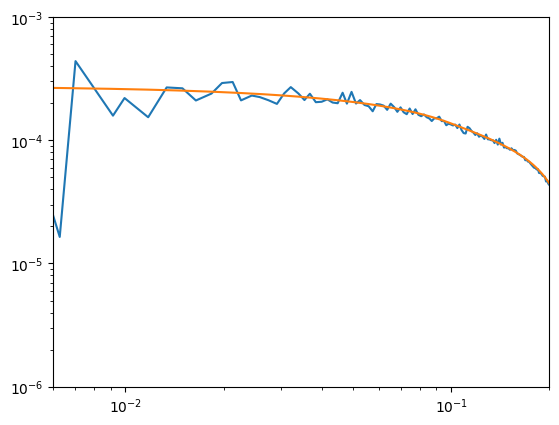

In [47]:
key = "g"
kinds = ["s", "t", "g"]
N = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]

index = 0
#plt.loglog(Ks, v, ls = "--")
plt.plot(ic_growth["k_avg"][:, index], ic_growth["power"][:, index])
#plt.plot(ic_growth_W["k_avg"][:, index], ic_growth_W["power"][:, index])

#plt.loglog(kn, powergn, marker = "o", ls = "", alpha = 0.4)


plt.loglog(Ks, N**-1)

#plt.loglog(kn_box, powergn_box/1.5**(2*3/2))

#plt.loglog(Ks, (np.interp(Ks, kn, powergn)*N**2)**-1.)

#plt.plot(ic_growth_3000["k_avg"][:, index], ic_growth_3000["power"][:, index])
#plt.plot(ic_growth_4000["k_avg"][:, index], ic_growth_4000["power"][:, index])
#plt.ylim(1e3, 1e5)
plt.ylim(1e-6, 1e-3)
plt.xlim(6e-3, 2e-1)

In [48]:
from abacusnbody.hod.zcv.ic_fields import filter_field as filt


def get_shift_rec(fft_field, box = 2000, j_factor = 1, filter_field = False):

    kgrid = get_kgrid(delta.shape[0])
    
    kmag = ((kgrid**2).sum(axis=0))**0.5
    
    Ptot_interp = jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
    gen_power = np.loadtxt(config['power_spectrum']['linear'])
    Plin_interp = jnp.interp(kmag, gen_power[:,0], gen_power[:,1])
    
    kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']
    
    selection = (kmag>=kmin) & (kmag<=kmax)
    #selection = gauss_filter(kmag)

    if filter_field:
        fft_field = filt(fft_field, ngrid, box, kmax)
    
    delta_A = fft_field*1/Ptot_interp*selection #IVF FIELD
    delta_A_real = irfftn(delta_A, overwrite_x=True, workers=nthread)

    delta_B = fft_field*1/Ptot_interp*Plin_interp*selection #WF FIELD

    inv_kmag_2 = 1/kmag**2
    inv_kmag_2[kmag == 0] = 0
    
    term = 0.
    tot_1 = 0.
    tot_2 = 0.
    for i in range(3):

        term_1 = delta_B*j_factor*kgrid[i]*inv_kmag_2
        term_2 = delta_B*j_factor*kgrid[i]

        term_1_real = irfftn(term_1, overwrite_x=True, workers=nthread)
        term_2_real = irfftn(term_2, overwrite_x=True, workers=nthread)
        
        product_1 = term_1_real*delta_A_real
        term_1 = rfftn(product_1, overwrite_x=False, workers=nthread)
        term_1 *= j_factor*kgrid[i]

        product_2 = term_2_real*delta_A_real
        term_2 = rfftn(product_2, overwrite_x=False, workers=nthread)
        term_2 *= j_factor*kgrid[i]*inv_kmag_2

        term += (term_1+term_2)*delta_A_real.size
        tot_1 += term_1
        tot_2 += term_2
    
    #delta_B_real = irfftn(delta_B, overwrite_x=True, workers=nthread)
    #product = delta_A_real*delta_B_real*17/21*delta_B.size
    #product_fft = rfftn(product, overwrite_x=False, workers=nthread)
    #product_fft *= 1 / product.size

    kbins = ngrid
    mubins = 4
    kbins, mubins = get_k_mu_edges(box, k_max, kbins, mubins, logk)
    
    power_product = calc_pk_from_deltak(
        term,
        box,
        kbins,
        mubins,
        field2_fft=None,
        poles=poles,
        squeeze_mu_axis=True,
        nthread=128,
    )

    return power_product, term

In [49]:
if False:
    pm = ParticleMesh(BoxSize=box, Nmesh=[ngrid]*3)
    real_field = pm.create(type='real')
    real_field[...] = ic*D_ratio  # fill the mesh
    
    delta_mesh = FieldMesh(real_field)
    delta_mesh_smoothed = delta_mesh#smoother.apply_smoothing(delta_mesh)
    
    out = FieldMesh(delta_mesh_smoothed.compute(mode='complex'))
    delta_ivf = out.apply(ivf_operator, kind='wavenumber', mode='complex')
    delta_ivf_real = delta_ivf.compute(mode="real")

In [50]:
if False:
    #0.5*(q/K+K/q)*q_i*K_i/q/K
    #0.5*(1/K**2+1/q**2)*q_i*K_i
    #1/K**2*K_i* q_i + K_i * 1/q**2*q_i
    
    #(1/q**2+1/K**2)*(-q_i)*K_i
    
    #1/q**2*(-q_i)*K_i d_q d_q'
    
    result = 0.
    result_A = 0.
    result_B = 0.
    
    for i in range(3):
        def shift_estimator_A(k3vec, val, idir = i):
            k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
            kmag = np.sqrt(k2)
            plinear_interp = plinf(kmag)
            invkmag = np.nan_to_num(1/kmag)
            invkmag[kmag == 0] = 0
            window = (kmag >= kmin) & (kmag <= kmax)
            return -k3vec[idir]*invkmag**2*plinear_interp*val*window
        
        def shift_estimator_A_(k3vec, val, idir = i):
            #k2 = sum(ki**2 for ki in k3vec)
            return k3vec[idir]*val
        
        def shift_estimator_B(k3vec, val, idir = i):
            k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
            kmag = np.sqrt(k2)
            plinear_interp = plinf(kmag)
            window = (kmag >= kmin) & (kmag <= kmax)
            return -k3vec[idir]*plinear_interp*val*window
        
        def shift_estimator_B_(k3vec, val, idir = i):
            k2 = sum(ki**2 for ki in k3vec)
            invkmag2 = np.nan_to_num(1/k2)
            invkmag2[k2 == 0] = 0
            return k3vec[idir]*invkmag2*val
    
    
        #out = FieldMesh(delta_ivf.compute(mode='complex'))
        delta_A = delta_ivf.apply(shift_estimator_A, kind='wavenumber', mode='complex')
        prod_A = (FieldMesh(delta_A.compute(mode="real")*delta_ivf_real))#.compute(mode='complex')
        part_A = (prod_A.apply(shift_estimator_A_, kind='wavenumber', mode='complex')).compute(mode="complex")
        
        #out = FieldMesh(delta_ivf.compute(mode='complex'))
        delta_B = delta_ivf.apply(shift_estimator_B, kind='wavenumber', mode='complex')
        prod_B = (FieldMesh(delta_B.compute(mode="real")*delta_ivf_real))#.compute(mode='complex')
        part_B = (prod_B.apply(shift_estimator_B_, kind='wavenumber', mode='complex')).compute(mode="complex")
        
        part = (part_A+part_B)
        result += part
    
        result_A += part_A
        result_B += part_B

In [51]:
#ic_shift, ic_shift_1, ic_shift_2  = get_shift_rec(ic_fft*D_ratio, j_factor = 1)

In [52]:
#size = irfftn(ic_fft, overwrite_x=True, workers=nthread).size

In [53]:
if False:
    for idir in range(3):
        # compute Psi_i
        def Psi_i_fcn(k3vec, val, idir=idir):
            kk = sum(ki**2 for ki in k3vec)  # k^2 on the mesh
            kk[kk == 0] = 1
            kmag = np.sqrt(kk)
            window = (kmag >= kmin) & (kmag <= kmax)
            plinear_interp = plinf(kmag)
            return -1.0j * k3vec[idir] * plinear_interp * val / kk * window
    
        Psi_i_x = delta_ivf.apply(
            Psi_i_fcn, mode='complex',
            kind='wavenumber').compute(mode='real')
    
        # compute nabla_i delta
        def grad_i_fcn(k3vec, val, idir=idir):
            kk = sum(ki**2 for ki in k3vec)  # k^2 on the mesh
            kk[kk == 0] = 1
            kmag = np.sqrt(kk)
            window = (kmag >= kmin) & (kmag <= kmax)
            return -1.0j * k3vec[idir] * val * window
    
        nabla_i_delta_x = delta_ivf.apply(
            grad_i_fcn, mode='complex',
            kind='wavenumber').compute(mode='real')
    
        # multiply and add up in x space
        if idir == 0:
            out_rfield = Psi_i_x * nabla_i_delta_x
        else:
            out_rfield += Psi_i_x * nabla_i_delta_x


    from nbodykit.algorithms.fftpower import FFTPower
    
    r = FFTPower(result, mode='1d')
    Pk = r.power
    
    # Extract k and P(k)
    kn = Pk['k']
    powersn = Pk['power'].real
    modesn = Pk['modes']


    r = FFTPower(result_A, mode='1d')
    Pk = r.power
    
    # Extract k and P(k)
    kn = Pk['k']
    powersn_A = Pk['power'].real
    modesn = Pk['modes']
    
    r = FFTPower(result_B, mode='1d')
    Pk = r.power
    
    # Extract k and P(k)
    kn = Pk['k']
    powersn_B = Pk['power'].real
    modesn = Pk['modes']
    
    r = FFTPower(out_rfield, mode='1d')
    Pk = r.power
    
    # Extract k and P(k)
    kn = Pk['k']
    powers_rfield = Pk['power'].real
    modesn = Pk['modes']

In [54]:
shift_j, term = get_shift_rec(ic_fft*D_ratio, j_factor = 1j, filter_field = False)

/tmp/ipykernel_76141/2979425112.py:27: RuntimeWarning: divide by zero encountered in divide
  inv_kmag_2 = 1/kmag**2


(0.006, 0.2)

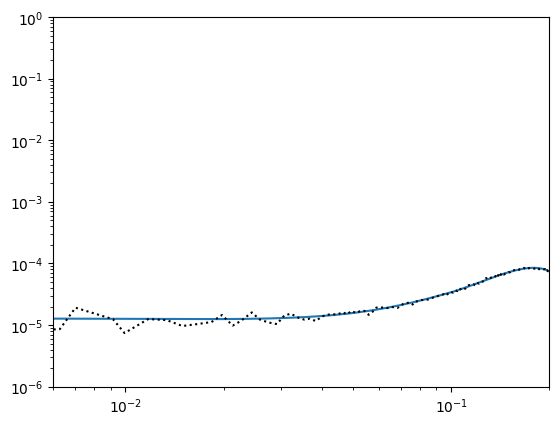

In [55]:
out_normalization_AB = np.load(output_dir / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()

key = "s"
kinds = ["s", "t", "g"]
N = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]

index = 0
plt.loglog(Ks, N**-1)

#plt.loglog(kn, powersn, marker = "o", ls = "", alpha = 0.4)
#plt.loglog(kn, powersn_A, marker = "o", ls = "", alpha = 0.4)
#plt.loglog(kn, powersn_B, marker = "o", ls = "", alpha = 0.4)

#plt.plot(ic_shift["k_avg"][:, index], ic_shift["power"][:, index]*size**2)
#plt.plot(ic_shift["k_avg"][:, index], ic_shift_1["power"][:, index]*size**2)
#plt.plot(ic_shift["k_avg"][:, index], ic_shift_2["power"][:, index]*size**2)

plt.plot(shift_j["k_avg"][:, index], shift_j["power"][:, index], ls = ":", color = "black")

#plt.loglog(kn, powers_rfield, marker = "o", ls = "", alpha = 0.4)

"""
key = "a"
Naa = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]
plt.loglog(Ks, Naa**-1, ls = "--")
#plt.loglog(Ks, v, ls = "--")


key = "b"
Nbb = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]
#plt.loglog(Ks, v, ls = ":")
plt.loglog(Ks, Nbb**-1, ls = ":")

plt.loglog(Ks, Naa**-1+Nbb**-1)
"""

plt.ylim(1e-6, 1)
plt.xlim(6e-3, 2e-1)

In [56]:
from abacusnbody.hod.zcv.ic_fields import filter_field as filt


def get_tidal_rec(fft_field, box = 2000, j_factor = 1, filter_field = False):

    kgrid = get_kgrid(delta.shape[0])
    
    kmag = ((kgrid**2).sum(axis=0))**0.5
    
    Ptot_interp = jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
    gen_power = np.loadtxt(config['power_spectrum']['linear'])
    Plin_interp = jnp.interp(kmag, gen_power[:,0], gen_power[:,1])
    
    kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']
    
    selection = (kmag>=kmin) & (kmag<=kmax)
    #selection = gauss_filter(kmag)

    if filter_field:
        fft_field = filt(fft_field, ngrid, box, kmax)
    
    delta_A = fft_field*1/Ptot_interp*selection #IVF FIELD
    delta_A_real = irfftn(delta_A, overwrite_x=True, workers=nthread)

    delta_B = fft_field*1/Ptot_interp*Plin_interp*selection #WF FIELD

    inv_kmag_2 = 1/kmag**2
    inv_kmag_2[kmag == 0] = 0
    
    term = 0.
    tot_1 = 0.
    tot_2 = 0.
    for i in range(3):

        term_1 = delta_B*j_factor*kgrid[i]*inv_kmag_2
        term_2 = delta_B*j_factor*kgrid[i]

        term_1_real = irfftn(term_1, overwrite_x=True, workers=nthread)
        term_2_real = irfftn(term_2, overwrite_x=True, workers=nthread)
        
        product_1 = term_1_real*delta_A_real
        term_1 = rfftn(product_1, overwrite_x=False, workers=nthread)
        term_1 *= j_factor*kgrid[i]

        product_2 = term_2_real*delta_A_real
        term_2 = rfftn(product_2, overwrite_x=False, workers=nthread)
        term_2 *= j_factor*kgrid[i]*inv_kmag_2

        term += (term_1+term_2)*delta_A_real.size
        tot_1 += term_1
        tot_2 += term_2
    
    #delta_B_real = irfftn(delta_B, overwrite_x=True, workers=nthread)
    #product = delta_A_real*delta_B_real*17/21*delta_B.size
    #product_fft = rfftn(product, overwrite_x=False, workers=nthread)
    #product_fft *= 1 / product.size

    kbins = ngrid
    mubins = 4
    kbins, mubins = get_k_mu_edges(box, k_max, kbins, mubins, logk)
    
    power_product = calc_pk_from_deltak(
        term,
        box,
        kbins,
        mubins,
        field2_fft=None,
        poles=poles,
        squeeze_mu_axis=True,
        nthread=128,
    )

    return power_product, term

### Use the non-linear field

In [62]:
#delta = tsc.tsc_parallel(pos['pos'], ngrid, box, nthread=nthread)
#delta /= np.mean(delta, dtype=np.float64)
#delta -= 1.

In [57]:
field_fft = rfftn(delta, overwrite_x=False, workers=nthread)
#field_fft *= 1 / delta.size

In [63]:
ic_growth_nl, growth_field = get_growth_rec(field_fft, return_field = True)

ic_growth_nl_filt, growth_field_filt = get_growth_rec(field_fft, return_field = True, filter_field = True)

/users/odarwish/abacusutils/abacusnbody/analysis/power_spectrum.py:789: RuntimeWarning: overflow encountered in multiply
  power *= Lbox**3
/users/odarwish/abacusutils/abacusnbody/analysis/power_spectrum.py:791: RuntimeWarning: overflow encountered in multiply
  binned_poles *= Lbox**3


In [64]:
#cross
kbins = ngrid
mubins = 4
kbins, mubins = get_k_mu_edges(box, k_max, kbins, mubins, logk)

power_product_linear = calc_pk_from_deltak(
    growth_field,
    box,
    kbins,
    mubins,
    field2_fft=ic_fft*D_ratio,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [65]:
power_product_nl_linear = calc_pk_from_deltak(
    field_fft,
    box,
    kbins,
    mubins,
    field2_fft=field_fft_disp,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)



power_product_growth_linear = calc_pk_from_deltak(
    growth_field,
    box,
    kbins,
    mubins,
    field2_fft=field_fft_disp,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

power_product_growth_linear_filt = calc_pk_from_deltak(
    growth_field_filt,
    box,
    kbins,
    mubins,
    field2_fft=field_fft_disp,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

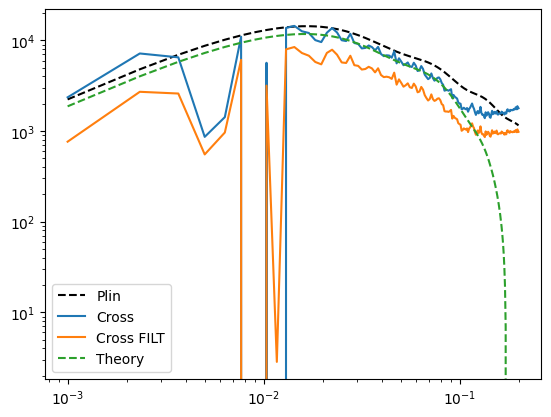

In [68]:
key = "g"
kinds = ["s", "t", "g"]

N = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]


#plt.loglog(power_product_nl_linear["k_avg"][:, index], power_product_nl_linear["power"][:, index]/ delta.size)
linear_pk_interp = jnp.interp(Ks, k, linear_pk)
plt.loglog(Ks, linear_pk_interp, "k--", label = "Plin")


v = np.interp(Ks, power_product_growth_linear["k_avg"][:, index], power_product_growth_linear["power"][:, index])
plt.loglog(Ks, v*np.array(N)/delta.size**2, label = "Cross")


v = np.interp(Ks, power_product_growth_linear_filt["k_avg"][:, index], power_product_growth_linear_filt["power"][:, index])
plt.loglog(Ks, v*np.array(N)/delta.size**2, label = "Cross FILT")

bias = 0
for kk in kinds:
    bias += (N*out_normalization_AB[(key, kk)])

linear_pk_interp = jnp.interp(Ks, k, linear_pk)
plt.loglog(Ks, bias*linear_pk_interp, ls = "--", label = "Theory")

plt.legend()


In [ ]:
shift_j, term = get_shift_rec(field_fft, j_factor = 1j, filter_field = False)

In [ ]:
shift_j_filt, term_filt = get_shift_rec(field_fft, j_factor = 1j, filter_field = True)

In [ ]:
power_product_shift_linear = calc_pk_from_deltak(
    term,
    box,
    kbins,
    mubins,
    field2_fft=field_fft_disp,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
power_product_shift_filt_linear = calc_pk_from_deltak(
    term_filt,
    box,
    kbins,
    mubins,
    field2_fft=field_fft_disp,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
key = "s"
kinds = ["s", "t", "g"]

N = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]

v = np.interp(Ks, power_product_shift_linear["k_avg"][:, index], power_product_shift_linear["power"][:, index])
plt.loglog(Ks, -v*np.array(N)/delta.size**2, label = "Estimator")

#v = np.interp(Ks, power_product_shift_linear["k_avg"][:, index], power_product_shift_filt_linear["power"][:, index])
#plt.loglog(Ks, -v*np.array(N)/delta.size**2)


bias = 0
for kk in kinds:
    bias += (N*out_normalization_AB[(kk, key)])

linear_pk_interp = jnp.interp(Ks, k, linear_pk)
plt.loglog(Ks, -bias*linear_pk_interp, ls = "--", label = "Theory")


(0.006, 0.2)

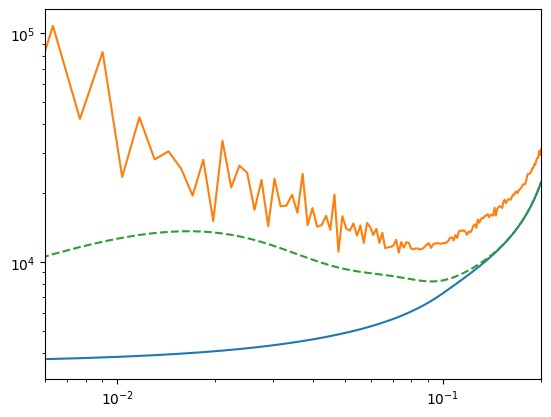

In [70]:
key = "g"
kinds = ["s", "t", "g"]

N = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]

plt.plot(Ks, N)

factor = 1/delta.size**2

#plt.loglog(power_product_nl_linear["k_avg"][:, index], 16*power_product_nl_linear["power"][:, index]/delta.size**4)

a, b = ic_growth_nl["k_avg"][:, index], np.nan_to_num(ic_growth_nl["power"][:, index]*factor**2)
b[0] = 0.
b = b.astype(float)
value = np.interp(Ks, a, b)*N**2.
plt.loglog(Ks, value)

a, b = ic_growth_nl_filt["k_avg"][:, index], np.nan_to_num(ic_growth_nl_filt["power"][:, index]*factor**2)
b[0] = 0.
b = b.astype(float)
value = np.interp(Ks, a, b)*N**2.
plt.loglog(Ks, value, label = "FILT")

bias = 0
for kk in kinds:
    bias += (N*out_normalization_AB[(key, kk)])

linear_pk_interp = jnp.interp(Ks, k, linear_pk)
plt.loglog(Ks, bias**2*linear_pk_interp+N, ls = "--")

#plt.plot(Ks, linear_pk_interp+N, "k")

#plt.ylim(1e-6, 1)
plt.xlim(6e-3, 2e-1)

plt.legend()


In [26]:
import jax
import jax.numpy as jnp

In [28]:
kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']

get_gauss_filter = lambda R: (lambda K: np.exp(-K**2*R**2/2))
R = 1/kmax
gauss_filter = get_gauss_filter(R)

In [ ]:
delta_A = field_fft*1/Ptot_interp*selection
delta_B = field_fft*1/Ptot_interp*Plin_interp*selection

delta_B_real = irfftn(delta_B, overwrite_x=True, workers=nthread)

inv_kmag = np.nan_to_num(1/kmag)
inv_kmag[0, 0, 0] = 0

delta_1 = 0
for i in range(3):
    delta_1_i = kgrid[i]*inv_kmag**2*delta_A
    delta_A_real_i = irfftn(delta_1_i, overwrite_x=True, workers=nthread)
    temp_i = delta_A_real_i*delta_B_real
    fft_temp_i = rfftn(temp_i, overwrite_x=False, workers=nthread)
    fft_temp_i *= kgrid[i]
    delta_1 += fft_temp_i

delta_2 = 0
for i in range(3):
    delta_1_i = kgrid[i]*delta_A
    delta_A_real_i = irfftn(delta_1_i, overwrite_x=True, workers=nthread)
    temp_i = delta_A_real_i*delta_B_real
    fft_temp_i = rfftn(temp_i, overwrite_x=False, workers=nthread)
    fft_temp_i *= kgrid[i]*inv_kmag**2
    delta_2 += fft_temp_i

delta_final = -2*0.5*(delta_1+delta_2)

product_fft = delta_final#rfftn(delta_final, overwrite_x=False, workers=nthread)
#product_fft *= product.size

power_product_shift = calc_pk_from_deltak(
    product_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
from scipy.fft import rfftn, irfftn

inv_kmag2 = np.zeros_like(kgrid[0])
kmag2 = np.sum(kgrid**2, axis=0)
inv_kmag2[kmag2 > 0] = 1.0 / kmag2[kmag2 > 0]  # avoid div by 0

out_rfield = 0
for idir in range(3):
    k_i = kgrid[idir]
    
    # Psi_i(k) = -i * k_i * delta(k) / k^2
    Psi_i_k = -1j * k_i * field_fft * inv_kmag2
    Psi_i_x = irfftn(Psi_i_k, overwrite_x=True, workers=nthread)#*Psi_i_k.size

    # grad_i delta(k) = -i * k_i * delta(k)
    grad_i_k = -1j * k_i * field_fft
    grad_i_x = irfftn(grad_i_k, overwrite_x=True, workers=nthread)#*grad_i_k.size

    # Real-space product: Psi_i(x) * grad_i delta(x)
    out_rfield += Psi_i_x * grad_i_x

# Final result in Fourier space
out_fft = rfftn(out_rfield, overwrite_x=False, workers=nthread)
#out_fft /= out_fft.size

power_out = calc_pk_from_deltak(
    out_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
with open('config_abacus_2.yaml', 'r') as f:
    config2 = yaml.safe_load(f)
output_config2 = config2['output']
filename_prefix = output_config2['filename_prefix']
filename_prefix = output_config2['filename_prefix']
output_dir2 = Path(output_config2['directory'])/config2['name']
out_normalization_AB_2 = np.load(output_dir2 / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()

In [ ]:
out = np.load(f"out.npy", allow_pickle = True).item()

In [ ]:
index = 1

plt.loglog(power_ic['k_avg'][:, index], power_ic['power'][:, index], ls = "--", c = "r")

plt.plot(gen_power[:,0], gen_power[:,1], ls='--', c='g')

plt.xlabel("k")
plt.ylabel("P")
plt.xlim(kmin_vol)
#plt.ylim(100)

In [ ]:
field_fft = rfftn(delta, overwrite_x=False, workers=nthread)

#field_fft = rfftn(delta, overwrite_x=True, workers=nthread)
#field_fft /= (
#    W[:, np.newaxis, np.newaxis]
#    * W[np.newaxis, :, np.newaxis]
#    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
#)

Ptot_interp = jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
gen_power = np.loadtxt(config['power_spectrum']['linear'])
Plin_interp = jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']
selection = (kmag>=kmin) & (kmag<=kmax)
selection = gauss_filter(kmag)

delta_A = field_fft*1/Ptot_interp*selection
delta_B = field_fft*1/Ptot_interp*Plin_interp*selection

delta_A_real = irfftn(delta_A, overwrite_x=True, workers=nthread)
delta_B_real = irfftn(delta_B, overwrite_x=True, workers=nthread)

product = delta_A_real*delta_B_real*17/21

product_fft = rfftn(product, overwrite_x=False, workers=nthread)
product_fft *= 1 / product.size

power_product = calc_pk_from_deltak(
    product_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
index = 1

#plt.plot(gen_nl_power[:,0], gen_nl_power[:,1], ls='--', c='g')

idxs = [0]#, 1, 2, 3, 4]
mean = 0
for sim_idx in idxs:
    power_product_file = np.load(output_dir/f'power_product_{sim_idx:03}.npy', allow_pickle = True).item()
    N = out_normalization_AB[('g', 'g')]**-1.
    p = np.interp(Ks, power_product_file['k_avg'][:, index], power_product_file['power'][:, index])*N**2
    plt.plot(Ks, p, alpha = 0.3)
    mean += p
    
plt.plot(Ks, N, color = "black")

plt.plot(Ks, out_normalization_AB_2[('g', 'g')]**-1., color = "red", ls = "--")

#plt.plot(Ks, mean/len(idxs), color = "blue")

p = np.interp(Ks, power_product['k_avg'][:, index], power_product['power'][:, index])*N**2
plt.plot(Ks, p, ls = "--")

key = "g"
kinds = ["s", "t", "g"]
N = out_normalization_AB_2[(key, key)]**-1.
bias = 0
for k in kinds:
    bias += N*out_normalization_AB_2[(key, k)]
total = bias**2*np.interp(Ks, gen_power[:,0], gen_power[:,1])+N
plt.plot(Ks, total, lw = 2)


#plt.plot(out["Ks"], out[('s', 's')]**-1.)


plt.xlabel("k")
plt.ylabel("P")
plt.xlim(kmin_vol, 0.25)
plt.ylim(ymin = 100, ymax = 2e4)
plt.xscale("log")
#plt.ylim(100)

In [ ]:
plt.plot(Ks, np.interp(Ks, power_product['k_avg'][:, index], power_product_shift['power'][:, index])*N**2)
plt.plot(Ks, np.interp(Ks, power_product['k_avg'][:, index], power_out['power'][:, index])*N**2)


kinds = ["s", "t", "g"]
N = out_normalization_AB[('s', 's')]**-1.
bias = 0
for k in kinds:
    bias += N*out_normalization_AB[('s', k)]
total = bias**2*np.interp(Ks, gen_power[:,0], gen_power[:,1])+N
plt.plot(Ks, total)
plt.loglog(Ks, N, color = "red")